# 01 — Exploratory Data Analysis (EDA)
## Rx Drug MMIX Analysis

This notebook focuses on exploratory data analysis for the Rx drug marketing mix dataset.

**EDA goals**
- Understand variable distributions and justify transformations
- Examine sales relationships with detailing and DTCA
- Inspect zero-value patterns in DTCA
- Assess trends over time
- Evaluate whether classes and agents have different baselines and response slopes
- Surface modeling implications for parametric and ML notebooks

**Standardized column names:** class, agent, year, detailing, direct_to_consumer_ad, actual_sales

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
df = pd.read_excel("data/MMM_Drug_Data.xlsx")
df = df.rename(columns={
    "Class": "class",
    "Agent": "agent",
    "Year": "year",
    "Detailing": "detailing",
    "Direct-to-Consumer Advertising (DTCA)": "direct_to_consumer_ad",
    "Actual Sales": "actual_sales"
})
df.head()

,class,agent,year,detailing,direct_to_consumer_ad,actual_sales
0,PPI,Prevacid,2013,43.8805,0.0000,2.9083
1,PPI,Prilosec,2013,41.6480,0.0000,14.7235
2,SSRI,Luvox,2013,22.3667,0.0000,0.9120
3,SSRI,Paxil,2013,57.4608,0.0000,11.2677
4,SSRI,Prozac,2013,84.5333,0.0000,20.2600


## 1. Initial Data Check
Confirm shape, column types, missing values, and time range.

In [3]:
print("Shape:", df.shape)
print("\nColumn types:")
display(df.dtypes.to_frame("dtype"))
print("\nMissing values:")
display(df.isna().sum().to_frame("missing_count"))
print(f"\nYears covered: {df['year'].min()} to {df['year'].max()}")
print(f"Number of classes: {df['class'].nunique()}")
print(f"Number of agents: {df['agent'].nunique()}")

Shape: (207, 6)

Column types:


,dtype
class,str
agent,str
year,int64
detailing,float64
direct_to_consumer_ad,float64
actual_sales,float64



Missing values:


,missing_count
class,0
agent,0
year,0
detailing,0
direct_to_consumer_ad,0
actual_sales,0



Years covered: 2013 to 2024
Number of classes: 3
Number of agents: 22


## 2. Panel Structure Check
With 22 agents over 12 years, a balanced panel would have 264 rows. We have 207, so some agents do not appear in all years.

In [4]:
panel = pd.crosstab(df["agent"], df["year"])

n_agents = df["agent"].nunique()
n_years = df["year"].nunique()
expected = n_agents * n_years

print(f"Expected rows (balanced panel): {expected}")
print(f"Actual rows: {len(df)}")
print(f"Missing agent-year combinations: {expected - len(df)}")
display(panel)

# Verify train/test agent overlap for time-based split
test_agents = set(df[df["year"] >= 2023]["agent"].unique())
train_agents = set(df[df["year"] <= 2020]["agent"].unique())
print(f"\nAgents in test (2023-2024) but NOT in train (<=2020): {test_agents - train_agents or 'None'}")
print(f"Agents in train (<=2020) but NOT in test (2023-2024): {train_agents - test_agents or 'None'}")

print('''
--- Observation ---
The panel is unbalanced: 57 missing agent-year cells. Several agents (Crestor,
Lexapro, Nexium, Pexeva) enter the dataset between 2018 and 2021. Earlier years
have fewer agents (10 in 2013 vs 22 by 2021). The train/test overlap check
confirms whether all test-period agents have training history — critical for
avoiding cold-start errors in models with agent fixed effects.
''')

Expected rows (balanced panel): 264
Actual rows: 207
Missing agent-year combinations: 57


year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
agent,,,,,,,,,,,,
Aciphex,0,0,0,1,1,1,1,1,1,1,1,1
Altoprev,0,0,0,0,0,0,1,1,1,1,1,1
Celexa,0,0,1,1,1,1,1,1,1,1,1,1
Crestor,0,0,0,0,0,0,0,1,1,1,1,1
Lescol,1,1,1,1,1,1,1,1,1,1,1,1
Lescol XL,0,0,0,0,1,1,1,1,1,1,1,1
Lexapro,0,0,0,0,0,0,1,1,1,1,1,1
Lipitor,0,1,1,1,1,1,1,1,1,1,1,1
Luvox,1,1,1,1,1,1,1,1,1,1,1,1



Agents in test (2023-2024) but NOT in train (<=2020): {'  Pexeva'}
Agents in train (<=2020) but NOT in test (2023-2024): None

--- Observation ---
The panel is unbalanced: 57 missing agent-year cells. Several agents (Crestor,
Lexapro, Nexium, Pexeva) enter the dataset between 2018 and 2021. Earlier years
have fewer agents (10 in 2013 vs 22 by 2021). The train/test overlap check
confirms whether all test-period agents have training history — critical for
avoiding cold-start errors in models with agent fixed effects.



## 3. Summary Statistics

In [5]:
summary = df[["actual_sales", "detailing", "direct_to_consumer_ad"]].describe()

summary_readable = summary.copy()
summary_readable["actual_sales"] = summary["actual_sales"].apply(lambda x: f"${x:,.2f}B")
summary_readable["detailing"] = summary["detailing"].apply(lambda x: f"${x:,.2f}M")
summary_readable["direct_to_consumer_ad"] = summary["direct_to_consumer_ad"].apply(lambda x: f"${x:,.2f}K")

print("=== Marketing Mix Summary ===")
print("Units — Sales: $B | Detailing: $M | DTCA: $K\n")
display(summary_readable)

print('''
--- Observation ---
Sales average $11.67B but the median is only $7.53B, confirming right skew.
Lipitor reaches $63.2B — roughly 5x the mean. Detailing averages $56M with
std of $54.9M (nearly equal to the mean), indicating wide dispersion. DTCA is
the most extreme: the median is effectively zero while the mean is $26.3K and
the max reaches $240K. More than half of observations have minimal or zero
consumer advertising.
''')

=== Marketing Mix Summary ===
Units — Sales: $B | Detailing: $M | DTCA: $K



,actual_sales,detailing,direct_to_consumer_ad
count,$207.00B,$207.00M,$207.00K
mean,$11.67B,$56.03M,$26.32K
std,$12.97B,$54.92M,$49.30K
min,$0.00B,$0.00M,$0.00K
25%,$0.99B,$3.86M,$0.00K
50%,$7.53B,$44.97M,$0.00K
75%,$19.61B,$85.12M,$39.36K
max,$63.22B,$243.33M,$240.35K



--- Observation ---
Sales average $11.67B but the median is only $7.53B, confirming right skew.
Lipitor reaches $63.2B — roughly 5x the mean. Detailing averages $56M with
std of $54.9M (nearly equal to the mean), indicating wide dispersion. DTCA is
the most extreme: the median is effectively zero while the mean is $26.3K and
the max reaches $240K. More than half of observations have minimal or zero
consumer advertising.



In [6]:
class_summary = (
    df.groupby("class")[["actual_sales", "detailing", "direct_to_consumer_ad"]]
    .agg(["mean", "std", "min", "max"])
    .sort_values(("actual_sales", "mean"), ascending=False)
)
display(class_summary)

actual_sales                        detailing                          \
               mean     std    min     max      mean     std    min      max   
class                                                                          
PPI         13.8355  8.9010 0.2054 28.9983   78.5221 45.7602 2.4873 172.8186   
Statin      12.4964 16.8686 0.0008 63.2186   48.5592 53.6895 0.1510 203.9765   
SSRI         9.5923 10.2513 0.0002 28.7552   49.9067 58.0119 0.0000 243.3303   

       direct_to_consumer_ad                          
                        mean     std    min      max  
class                                                 
PPI                  42.9419 69.4016 0.0000 240.3550  
Statin               31.7618 49.7525 0.0000 213.3158  
SSRI                 11.2310 24.9208 0.0000 114.1849

In [7]:
agent_summary = (
    df.groupby("agent")[["actual_sales", "detailing", "direct_to_consumer_ad"]]
    .agg(["mean", "std"])
    .sort_values(("actual_sales", "mean"), ascending=False)
)
display(agent_summary.head(10))

actual_sales         detailing         direct_to_consumer_ad        
                 mean     std      mean     std                  mean     std
agent                                                                        
Lipitor       47.0275 18.3517  124.0093 46.9129               80.7884 54.8270
Zoloft        21.1441  7.5867   80.4162 35.6358               30.3664 39.4560
Lexapro       19.1402 10.0567  192.7008 62.1090                0.7499  0.9507
Nexium        18.7587  8.0302  153.0828 17.1630              182.8566 52.3960
Prevacid      17.8747  7.1570   92.0651 28.5974               38.7137 46.8363
Zocor         17.6050  6.7210   70.3491 33.8493               54.1879 33.5656
Prilosec      14.1557 11.6924   27.1468 29.3306               23.3186 37.2672
Paxil         12.8184  9.7939   43.0369 35.4293               22.7528 36.1984
Protonix      12.0249  5.9005   83.2735 13.3897                3.3244  6.2799
Prozac        11.2791 10.8142   36.9844 37.5657                7.0337 13.0253

## 4. Distributions and Transformation Justification
All three variables are expected to be right-skewed. We check raw distributions, compute skewness, apply log(1+x) transformations, and compare.

In [8]:
skew_raw = df[["actual_sales", "detailing", "direct_to_consumer_ad"]].skew()
display(skew_raw.to_frame("raw_skewness"))

print('''
--- Observation ---
All three variables show strong positive skew: sales (1.71), detailing (1.04),
DTCA (2.30). DTCA is the most skewed due to its zero-inflation. These
distributions violate linear regression assumptions of normality and constant
variance, motivating a log transformation.
''')

,raw_skewness
actual_sales,1.7127
detailing,1.0358
direct_to_consumer_ad,2.2988



--- Observation ---
All three variables show strong positive skew: sales (1.71), detailing (1.04),
DTCA (2.30). DTCA is the most skewed due to its zero-inflation. These
distributions violate linear regression assumptions of normality and constant
variance, motivating a log transformation.



### Feature Engineering
Create log-transformed variables using log(1+x) to safely handle zeros. Also create a binary zero-DTCA indicator for potential use in modeling.

In [9]:
df["log_sales"] = np.log1p(df["actual_sales"])
df["log_detailing"] = np.log1p(df["detailing"])
df["log_dtca"] = np.log1p(df["direct_to_consumer_ad"])
df["dtca_zero"] = (df["direct_to_consumer_ad"] == 0).astype(int)

print("Log transformation applied. Columns added: log_sales, log_detailing, log_dtca, dtca_zero")

Log transformation applied. Columns added: log_sales, log_detailing, log_dtca, dtca_zero


In [10]:
skew_after = df[["log_sales", "log_detailing", "log_dtca"]].skew()

skew_compare = pd.DataFrame({
    "Raw": df[["actual_sales", "detailing", "direct_to_consumer_ad"]].skew().values,
    "Log": skew_after.values
}, index=["Sales", "Detailing", "DTCA"])
display(skew_compare)

print('''
--- Observation ---
Log transformation reduces skewness substantially: sales from 1.71 to -0.16
(near symmetric), detailing from 1.04 to -0.61 (acceptable), DTCA from 2.30
to 0.83 (improved but still skewed due to the zero-value mass).
''')

,Raw,Log
Sales,1.7127,-0.1557
Detailing,1.0358,-0.6077
DTCA,2.2988,0.8257



--- Observation ---
Log transformation reduces skewness substantially: sales from 1.71 to -0.16
(near symmetric), detailing from 1.04 to -0.61 (acceptable), DTCA from 2.30
to 0.83 (improved but still skewed due to the zero-value mass).



### Raw vs Log-Transformed Distributions

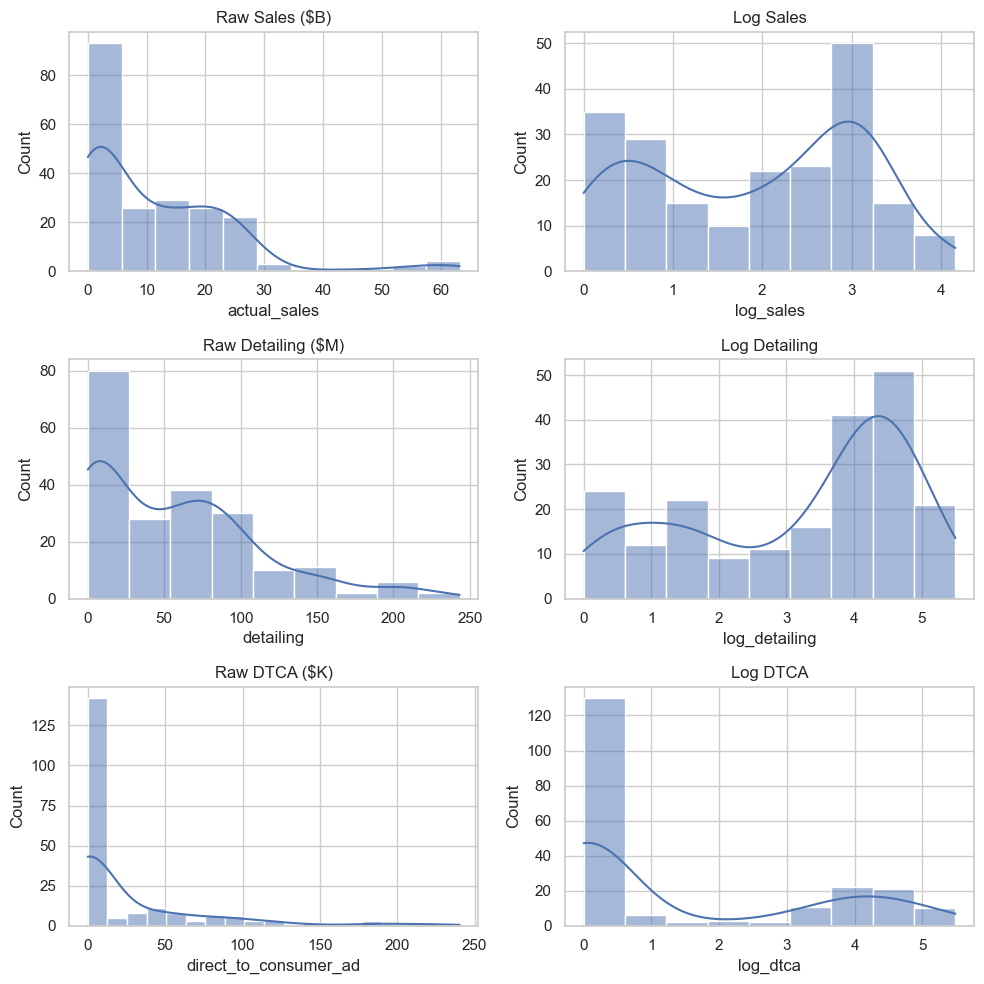

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(10, 10))

sns.histplot(df["actual_sales"], kde=True, ax=axes[0,0])
axes[0,0].set_title("Raw Sales ($B)")
sns.histplot(df["log_sales"], kde=True, ax=axes[0,1])
axes[0,1].set_title("Log Sales")

sns.histplot(df["detailing"], kde=True, ax=axes[1,0])
axes[1,0].set_title("Raw Detailing ($M)")
sns.histplot(df["log_detailing"], kde=True, ax=axes[1,1])
axes[1,1].set_title("Log Detailing")

sns.histplot(df["direct_to_consumer_ad"], kde=True, ax=axes[2,0])
axes[2,0].set_title("Raw DTCA ($K)")
sns.histplot(df["log_dtca"], kde=True, ax=axes[2,1])
axes[2,1].set_title("Log DTCA")

plt.tight_layout()
plt.show()

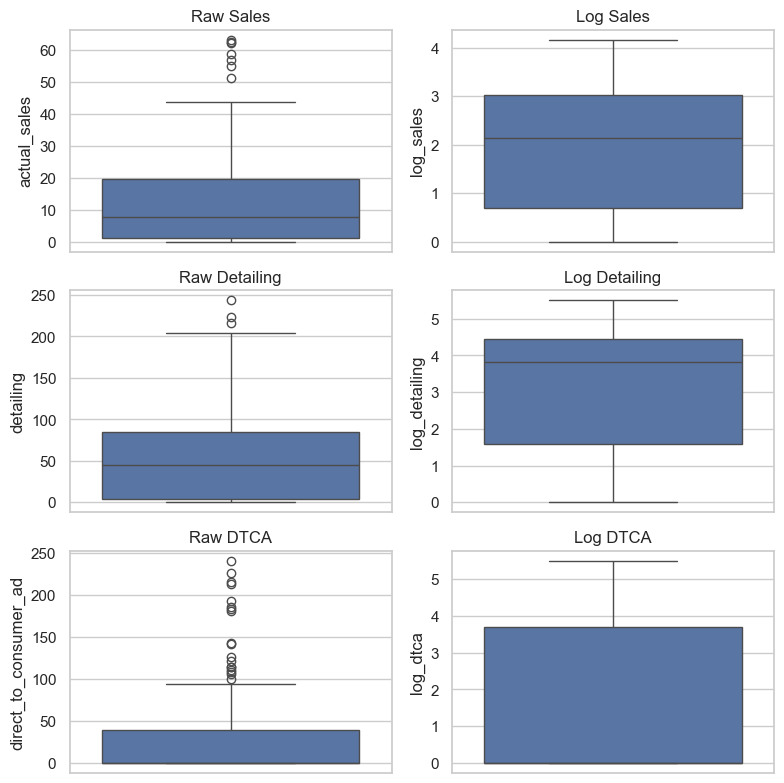

In [12]:
fig, axes = plt.subplots(3, 2, figsize=(8, 8))

sns.boxplot(y=df["actual_sales"], ax=axes[0,0]); axes[0,0].set_title("Raw Sales")
sns.boxplot(y=df["log_sales"], ax=axes[0,1]); axes[0,1].set_title("Log Sales")
sns.boxplot(y=df["detailing"], ax=axes[1,0]); axes[1,0].set_title("Raw Detailing")
sns.boxplot(y=df["log_detailing"], ax=axes[1,1]); axes[1,1].set_title("Log Detailing")
sns.boxplot(y=df["direct_to_consumer_ad"], ax=axes[2,0]); axes[2,0].set_title("Raw DTCA")
sns.boxplot(y=df["log_dtca"], ax=axes[2,1]); axes[2,1].set_title("Log DTCA")

plt.tight_layout()
plt.show()

### Raw vs Log-Log Relationship: Sales and Detailing

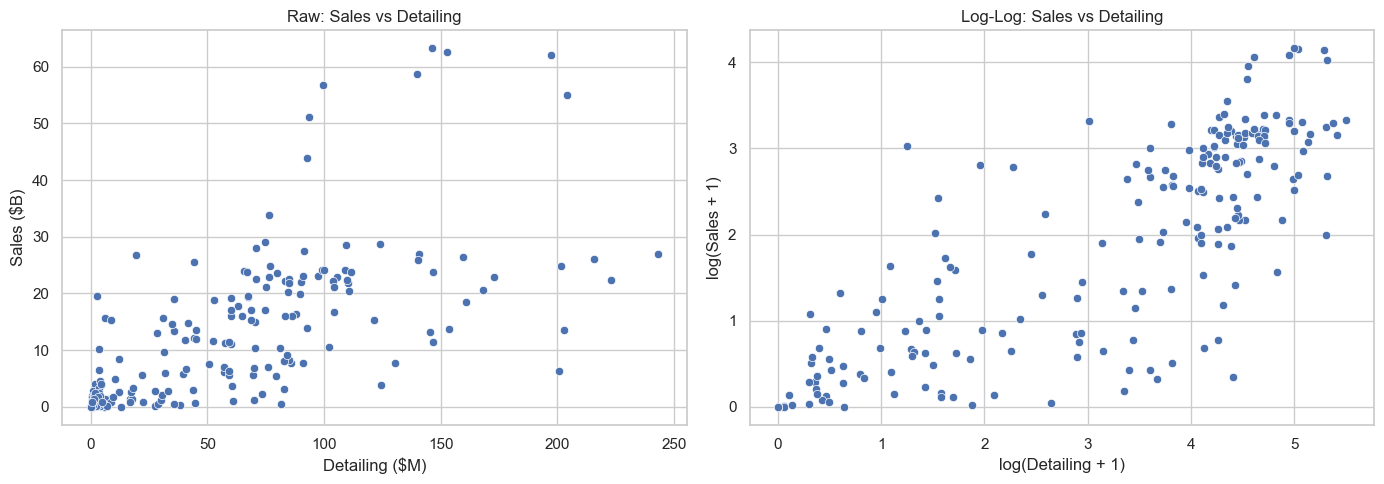


--- Observation ---
The raw scatterplot shows a dispersed, non-linear cloud. The log-log version
reveals a much cleaner positive linear gradient, confirming a multiplicative
relationship between marketing effort and sales. This directly justifies a
log-log parametric specification where coefficients are interpretable as
elasticities.



In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=df["detailing"], y=df["actual_sales"], ax=axes[0])
axes[0].set_title("Raw: Sales vs Detailing")
axes[0].set_xlabel("Detailing ($M)")
axes[0].set_ylabel("Sales ($B)")

sns.scatterplot(x=df["log_detailing"], y=df["log_sales"], ax=axes[1])
axes[1].set_title("Log-Log: Sales vs Detailing")
axes[1].set_xlabel("log(Detailing + 1)")
axes[1].set_ylabel("log(Sales + 1)")

plt.tight_layout()
plt.show()

print('''
--- Observation ---
The raw scatterplot shows a dispersed, non-linear cloud. The log-log version
reveals a much cleaner positive linear gradient, confirming a multiplicative
relationship between marketing effort and sales. This directly justifies a
log-log parametric specification where coefficients are interpretable as
elasticities.
''')

## 5. Zero-DTCA Structure
Zero DTCA is not just "small DTCA" — it may represent a fundamentally different marketing regime where no consumer advertising program exists.

In [33]:
zero_dtca = (df["direct_to_consumer_ad"] == 0).sum()
total = len(df)
print(f"Zero-DTCA observations: {zero_dtca} of {total} ({zero_dtca/total:.1%})")

print("\nZero-DTCA by class:")
display(pd.crosstab(df["class"], df["dtca_zero"]).rename(columns={0: "Non-zero", 1: "Zero"}))

print("\nZero-DTCA by year:")
display(pd.crosstab(df["year"], df["dtca_zero"]).rename(columns={0: "Non-zero", 1: "Zero"}))

print('''
--- Observation ---

Nearly half of observations (47%) have zero consumer advertising, with the
highest concentration in SSRIs (58%). This is not a data quality issue. It
reflects a deliberate business choice where these brands rely entirely on
physician detailing and do not run consumer advertising programs. Our model
accounts for this through the log(1+DTCA) transformation, and a binary
indicator is available if residual diagnostics suggest the continuous term
alone is insufficient. SSRI-specific DTCA elasticity estimates should be
interpreted with caution, as only 34 of 81 SSRI observations have non-zero
consumer advertising spend to identify the response slope.
''')

Zero-DTCA observations: 98 of 207 (47.3%)

Zero-DTCA by class:


dtca_zero,Non-zero,Zero
class,,
PPI,32,16
SSRI,34,47
Statin,43,35



Zero-DTCA by year:


dtca_zero,Non-zero,Zero
year,,
2013,3,7
2014,5,6
2015,6,6
2016,6,7
2017,7,8
2018,12,5
2019,12,8
2020,10,11
2021,13,9



--- Observation ---

Nearly half of observations (47%) have zero consumer advertising, with the
highest concentration in SSRIs (58%). This is not a data quality issue. It
reflects a deliberate business choice where these brands rely entirely on
physician detailing and do not run consumer advertising programs. Our model
accounts for this through the log(1+DTCA) transformation, and a binary
indicator is available if residual diagnostics suggest the continuous term
alone is insufficient. SSRI-specific DTCA elasticity estimates should be
interpreted with caution, as only 34 of 81 SSRI observations have non-zero
consumer advertising spend to identify the response slope.



## 6. Trends Over Time

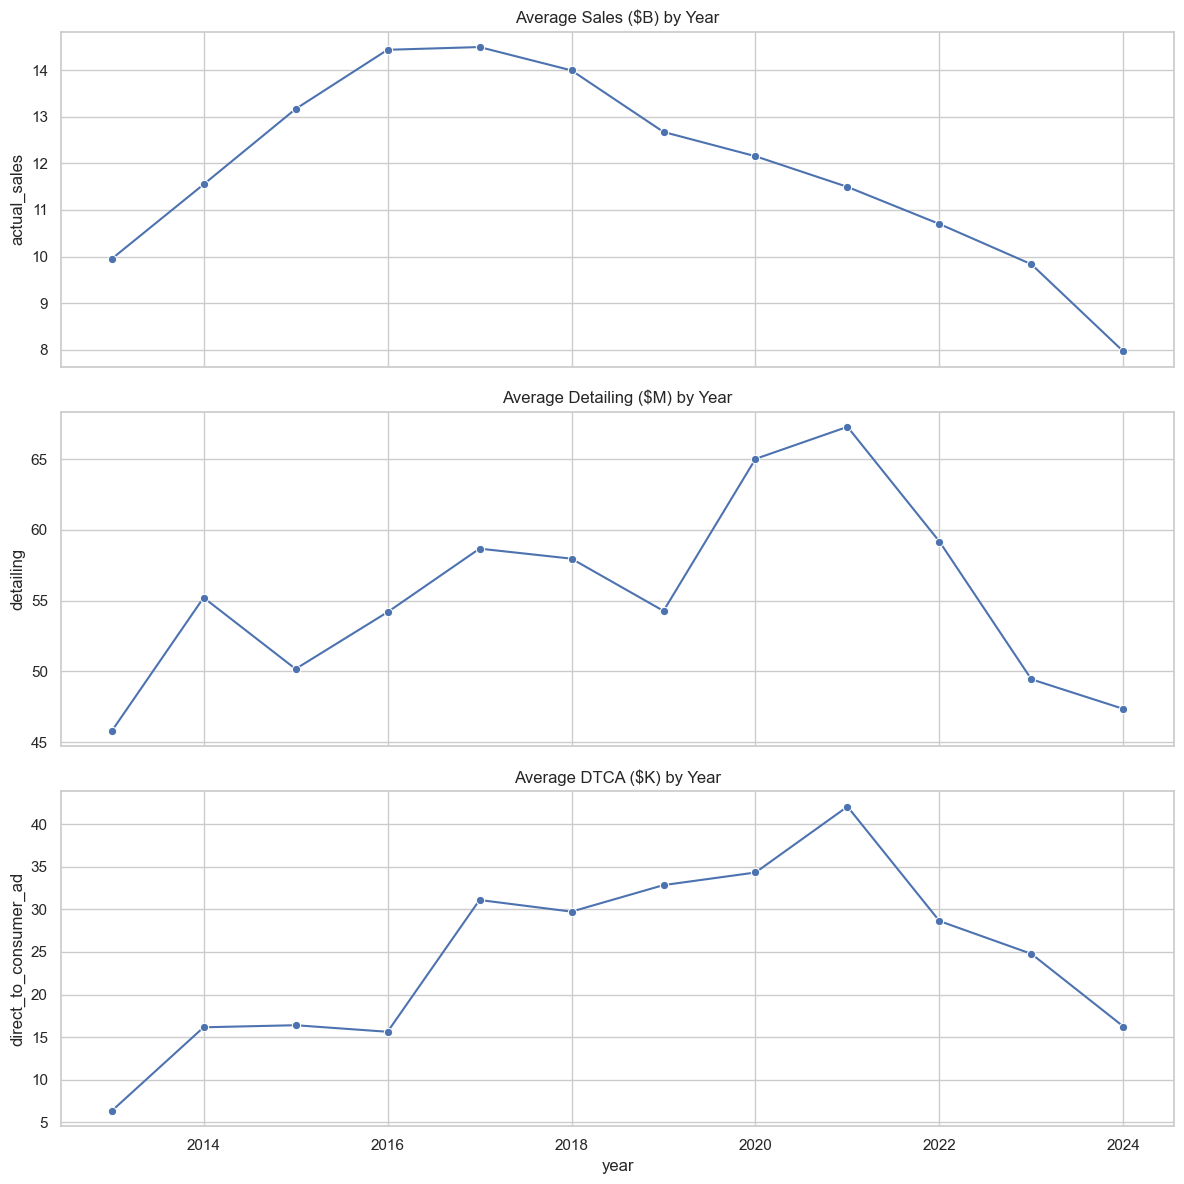

In [16]:
yearly = (
    df.groupby("year")[["actual_sales", "detailing", "direct_to_consumer_ad"]]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

sns.lineplot(data=yearly, x="year", y="actual_sales", marker="o", ax=axes[0])
axes[0].set_title("Average Sales ($B) by Year")

sns.lineplot(data=yearly, x="year", y="detailing", marker="o", ax=axes[1])
axes[1].set_title("Average Detailing ($M) by Year")

sns.lineplot(data=yearly, x="year", y="direct_to_consumer_ad", marker="o", ax=axes[2])
axes[2].set_title("Average DTCA ($K) by Year")

plt.tight_layout()
plt.show()

### Trends by Class
The aggregate trend can hide class-level differences.

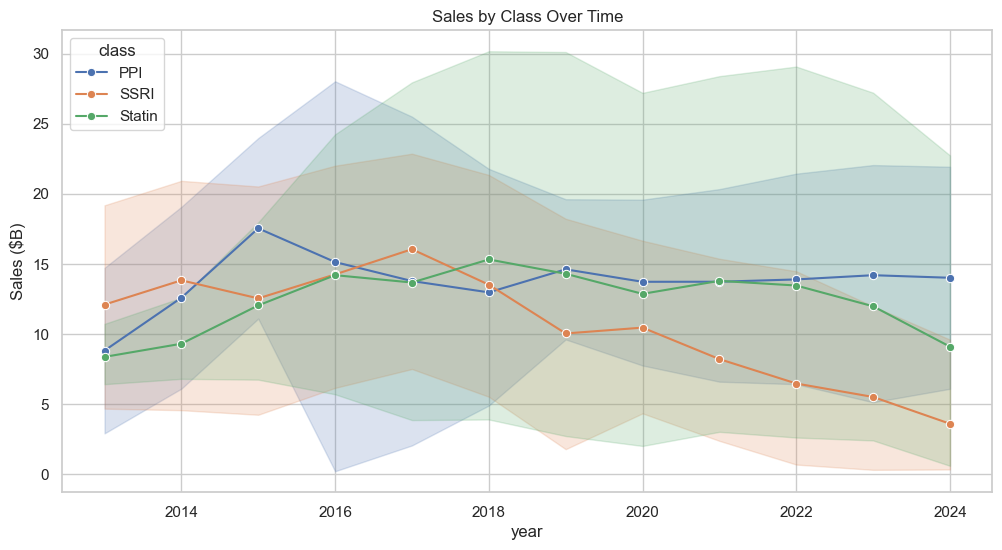


--- Observation ---
Sales rise from ~$10B (2013) to ~$14.5B (2019-2020), then decline to ~$8B by
2024. Detailing and DTCA follow similar arcs. The post-2020 simultaneous
decline suggests a market-wide structural shift (patent cliffs, generic entry).

By class: PPI peaks around 2015-2016 then declines. SSRI shows a modest peak
~2018 with sharper late decline. Statin is more stable through 2022, driven by
Lipitor. These divergent trajectories rule out a linear time trend — year
fixed effects C(Year) are necessary.



In [17]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="year", y="actual_sales", hue="class", marker="o")
plt.title("Sales by Class Over Time")
plt.ylabel("Sales ($B)")
plt.show()

print('''
--- Observation ---
Sales rise from ~$10B (2013) to ~$14.5B (2019-2020), then decline to ~$8B by
2024. Detailing and DTCA follow similar arcs. The post-2020 simultaneous
decline suggests a market-wide structural shift (patent cliffs, generic entry).

By class: PPI peaks around 2015-2016 then declines. SSRI shows a modest peak
~2018 with sharper late decline. Statin is more stable through 2022, driven by
Lipitor. These divergent trajectories rule out a linear time trend — year
fixed effects C(Year) are necessary.
''')

## 7. Class and Agent Baselines

In [18]:
avg_sales_by_class = (
    df.groupby("class")["actual_sales"]
    .mean()
    .sort_values(ascending=False)
    .to_frame("avg_sales_B")
)
display(avg_sales_by_class)

,avg_sales_B
class,
PPI,13.8355
Statin,12.4964
SSRI,9.5923


In [19]:
avg_sales_by_agent = (
    df.groupby("agent")["actual_sales"]
    .mean()
    .sort_values(ascending=False)
    .to_frame("avg_sales_B")
)
display(avg_sales_by_agent.head(15))

,avg_sales_B
agent,
Lipitor,47.0275
Zoloft,21.1441
Lexapro,19.1402
Nexium,18.7587
Prevacid,17.8747
Zocor,17.6050
Prilosec,14.1557
Paxil,12.8184
Protonix,12.0249


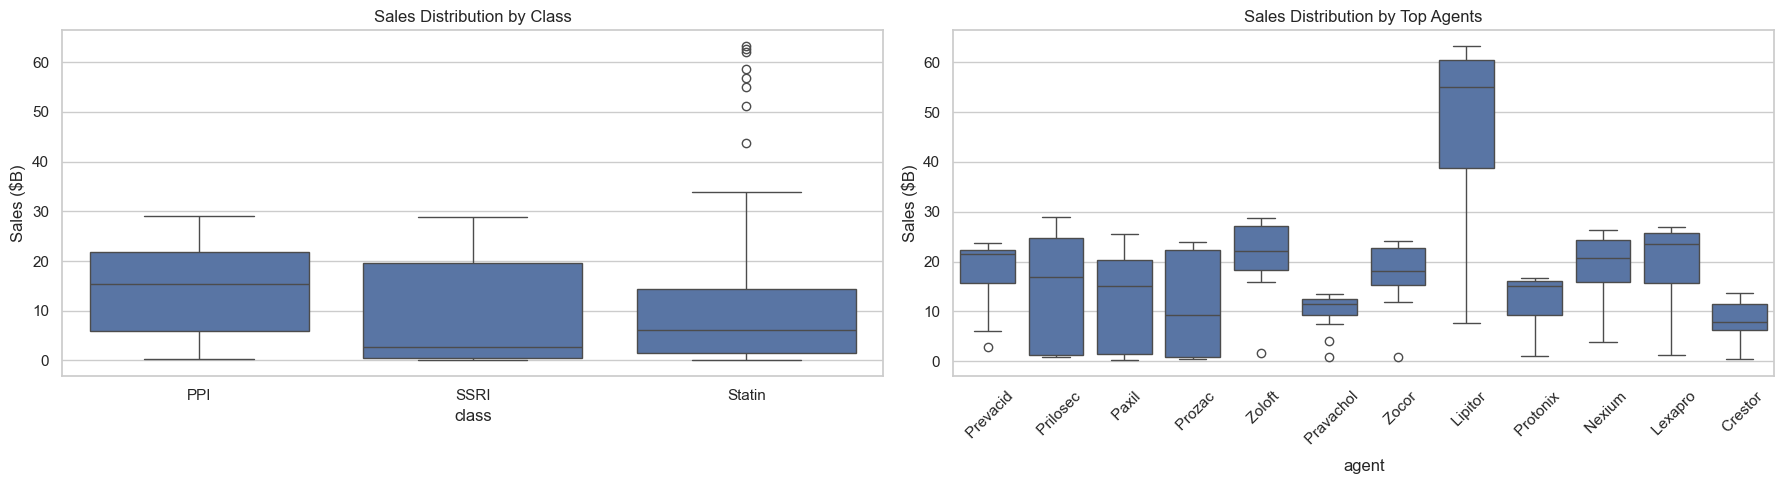


--- Observation ---
Class baselines differ: PPI $13.8B, Statin $12.5B, SSRI $9.6B. But agent
baselines vary far more — Lipitor ($47B) is roughly 50x Luvox ($0.9B) and
alone accounts for ~20% of total dataset sales. The Statin boxplot shows
extreme Lipitor-driven outliers. Without agent-level controls (fixed effects
or random intercepts), the model would confound brand equity with marketing
responsiveness.



In [20]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.boxplot(data=df, x="class", y="actual_sales", ax=axes[0])
axes[0].set_title("Sales Distribution by Class")
axes[0].set_ylabel("Sales ($B)")

top_agents = avg_sales_by_agent.head(12).index
sns.boxplot(data=df[df["agent"].isin(top_agents)], x="agent", y="actual_sales", ax=axes[1])
axes[1].set_title("Sales Distribution by Top Agents")
axes[1].set_ylabel("Sales ($B)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print('''
--- Observation ---
Class baselines differ: PPI $13.8B, Statin $12.5B, SSRI $9.6B. But agent
baselines vary far more — Lipitor ($47B) is roughly 50x Luvox ($0.9B) and
alone accounts for ~20% of total dataset sales. The Statin boxplot shows
extreme Lipitor-driven outliers. Without agent-level controls (fixed effects
or random intercepts), the model would confound brand equity with marketing
responsiveness.
''')

## 8. Raw-Scale Response Relationships

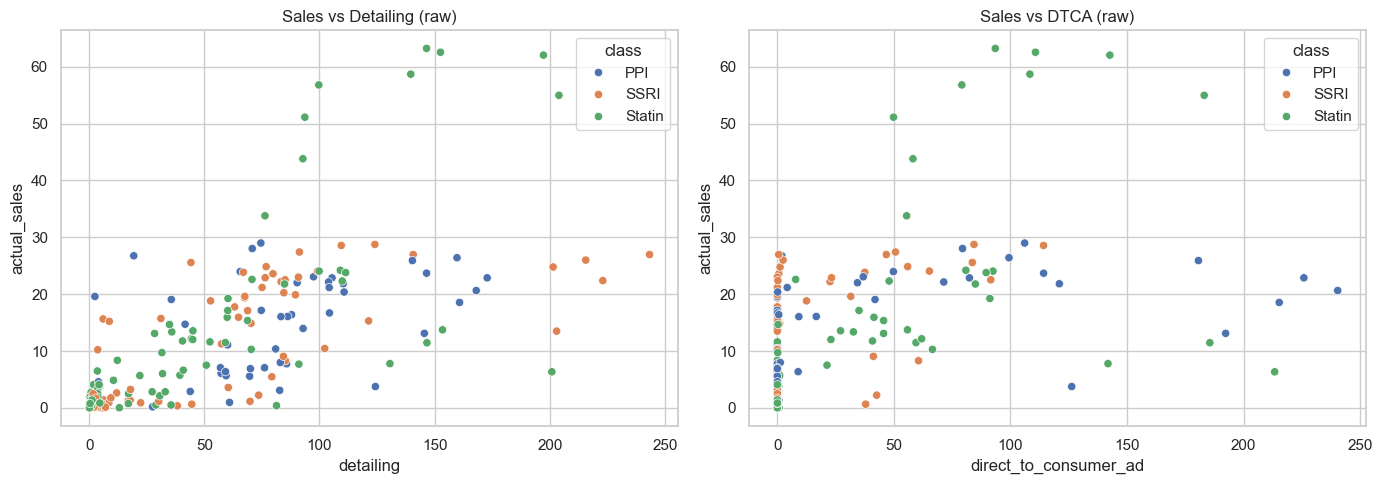


--- Observation ---
Sales vs Detailing shows a positive but noisy association. Much of the
correlation is driven by brand size (big brands both spend more and sell
more). Sales vs DTCA is weaker — the massive cluster at DTCA=0 makes the
raw-scale plot hard to interpret. Both plots show class-level clustering.



In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="detailing", y="actual_sales", hue="class", ax=axes[0])
axes[0].set_title("Sales vs Detailing (raw)")

sns.scatterplot(data=df, x="direct_to_consumer_ad", y="actual_sales", hue="class", ax=axes[1])
axes[1].set_title("Sales vs DTCA (raw)")

plt.tight_layout()
plt.show()

print('''
--- Observation ---
Sales vs Detailing shows a positive but noisy association. Much of the
correlation is driven by brand size (big brands both spend more and sell
more). Sales vs DTCA is weaker — the massive cluster at DTCA=0 makes the
raw-scale plot hard to interpret. Both plots show class-level clustering.
''')

## 9. Log-Transformed Response Relationships

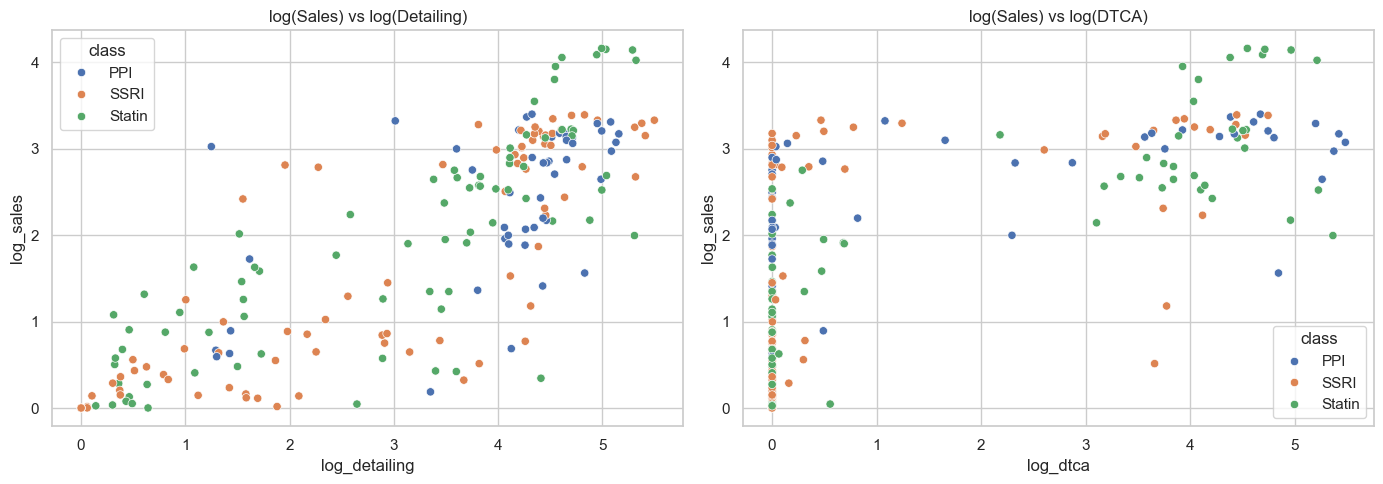

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="log_detailing", y="log_sales", hue="class", ax=axes[0])
axes[0].set_title("log(Sales) vs log(Detailing)")

sns.scatterplot(data=df, x="log_dtca", y="log_sales", hue="class", ax=axes[1])
axes[1].set_title("log(Sales) vs log(DTCA)")

plt.tight_layout()
plt.show()

### Faceted Response Plots by Class
Faceting reveals whether the response *slope* differs by class — the key question for deciding on interaction terms.

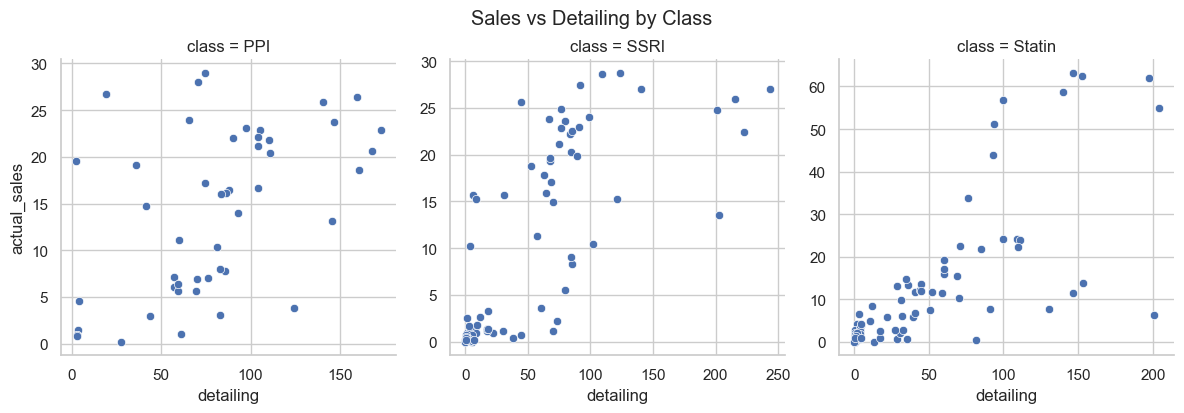

In [23]:
g = sns.FacetGrid(df, col="class", col_wrap=3, height=4, sharex=False, sharey=False)
g.map_dataframe(sns.scatterplot, x="detailing", y="actual_sales")
g.fig.suptitle("Sales vs Detailing by Class", y=1.03)
plt.show()

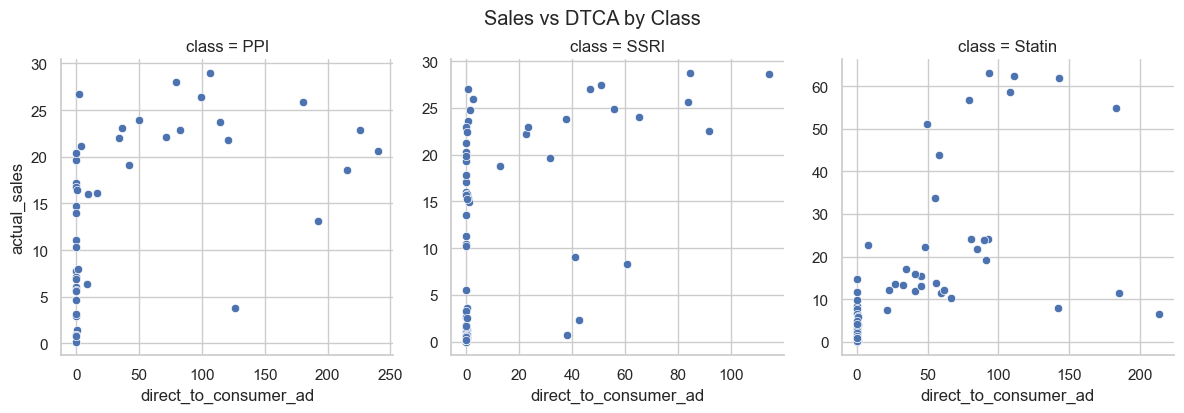


--- Observation ---
Detailing: PPI shows a flat-ish gradient. SSRI shows a stronger positive
slope. Statin is dispersed with Lipitor dominating the upper range.

DTCA: PPI shows a clear positive relationship (Nexium-driven). SSRI has most
points at zero DTCA — slope estimation is unreliable. Statin shows moderate
positive association among non-zero observations.

These slope differences across classes provide visual evidence for including
log_detailing:C(Class) and log_dtca:C(Class) interaction terms. PPI appears
more DTCA-responsive; SSRI appears more detailing-responsive.



In [24]:
g = sns.FacetGrid(df, col="class", col_wrap=3, height=4, sharex=False, sharey=False)
g.map_dataframe(sns.scatterplot, x="direct_to_consumer_ad", y="actual_sales")
g.fig.suptitle("Sales vs DTCA by Class", y=1.03)
plt.show()

print('''
--- Observation ---
Detailing: PPI shows a flat-ish gradient. SSRI shows a stronger positive
slope. Statin is dispersed with Lipitor dominating the upper range.

DTCA: PPI shows a clear positive relationship (Nexium-driven). SSRI has most
points at zero DTCA — slope estimation is unreliable. Statin shows moderate
positive association among non-zero observations.

These slope differences across classes provide visual evidence for including
log_detailing:C(Class) and log_dtca:C(Class) interaction terms. PPI appears
more DTCA-responsive; SSRI appears more detailing-responsive.
''')

## 10. Correlation Matrix

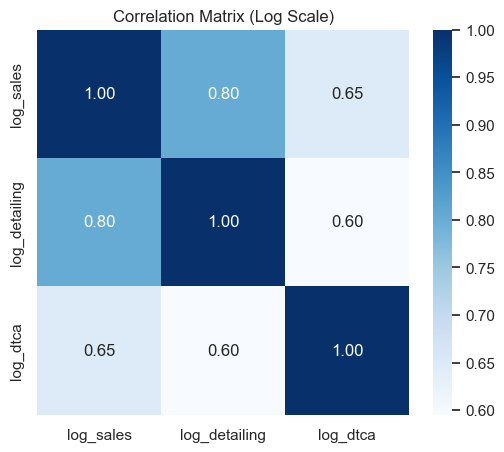


--- Observation ---
log(Sales)-log(Detailing): r = 0.80 — strong. log(Sales)-log(DTCA): r = 0.65
— moderate. log(Detailing)-log(DTCA): r = 0.60 — moderate. The 0.60
correlation between marketing inputs is manageable for estimation but means
multicollinearity could inflate standard errors. Once agent fixed effects
absorb brand-size differences, the within-agent correlation may be lower.



In [25]:
corr = df[["log_sales", "log_detailing", "log_dtca"]].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Matrix (Log Scale)")
plt.show()

print('''
--- Observation ---
log(Sales)-log(Detailing): r = 0.80 — strong. log(Sales)-log(DTCA): r = 0.65
— moderate. log(Detailing)-log(DTCA): r = 0.60 — moderate. The 0.60
correlation between marketing inputs is manageable for estimation but means
multicollinearity could inflate standard errors. Once agent fixed effects
absorb brand-size differences, the within-agent correlation may be lower.
''')

## 11. Detailing vs DTCA Collinearity
Do the two marketing inputs move together? Does the pattern differ by class?

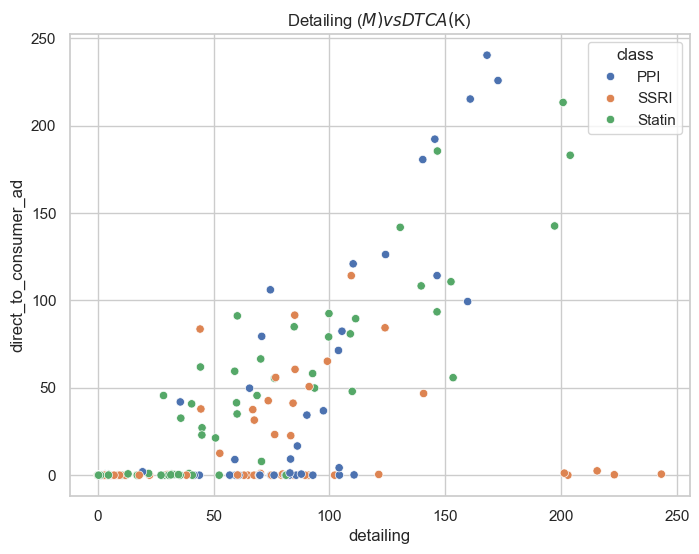


--- Observation ---
Three distinct class-level patterns:
  PPI (blue): Positive joint investment — brands detail heavily AND advertise.
  Statin (green): Similar pattern, driven by Lipitor and Crestor.
  SSRI (orange): Detailing-only strategy. Most SSRIs cluster along the x-axis
    (high detailing, near-zero DTCA).

This means SSRIs provide natural identification for the detailing effect — in
that class, sales variation comes almost entirely from detailing, not DTCA.
PPI/Statin classes will have harder coefficient separation because both inputs
co-move. Class interactions help by leveraging this structural difference.



In [26]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="detailing", y="direct_to_consumer_ad", hue="class")
plt.title("Detailing ($M) vs DTCA ($K)")
plt.show()

print('''
--- Observation ---
Three distinct class-level patterns:
  PPI (blue): Positive joint investment — brands detail heavily AND advertise.
  Statin (green): Similar pattern, driven by Lipitor and Crestor.
  SSRI (orange): Detailing-only strategy. Most SSRIs cluster along the x-axis
    (high detailing, near-zero DTCA).

This means SSRIs provide natural identification for the detailing effect — in
that class, sales variation comes almost entirely from detailing, not DTCA.
PPI/Statin classes will have harder coefficient separation because both inputs
co-move. Class interactions help by leveraging this structural difference.
''')

## 12. Within-Agent Variation
In panel data, the relevant question is not just "do bigger brands spend more?" but "when a brand changes its marketing, do its sales change too?" These trajectories show within-agent co-movement over time.

Plotting agents: ['  Prevacid', '  Prilosec', '  Luvox', '  Paxil']


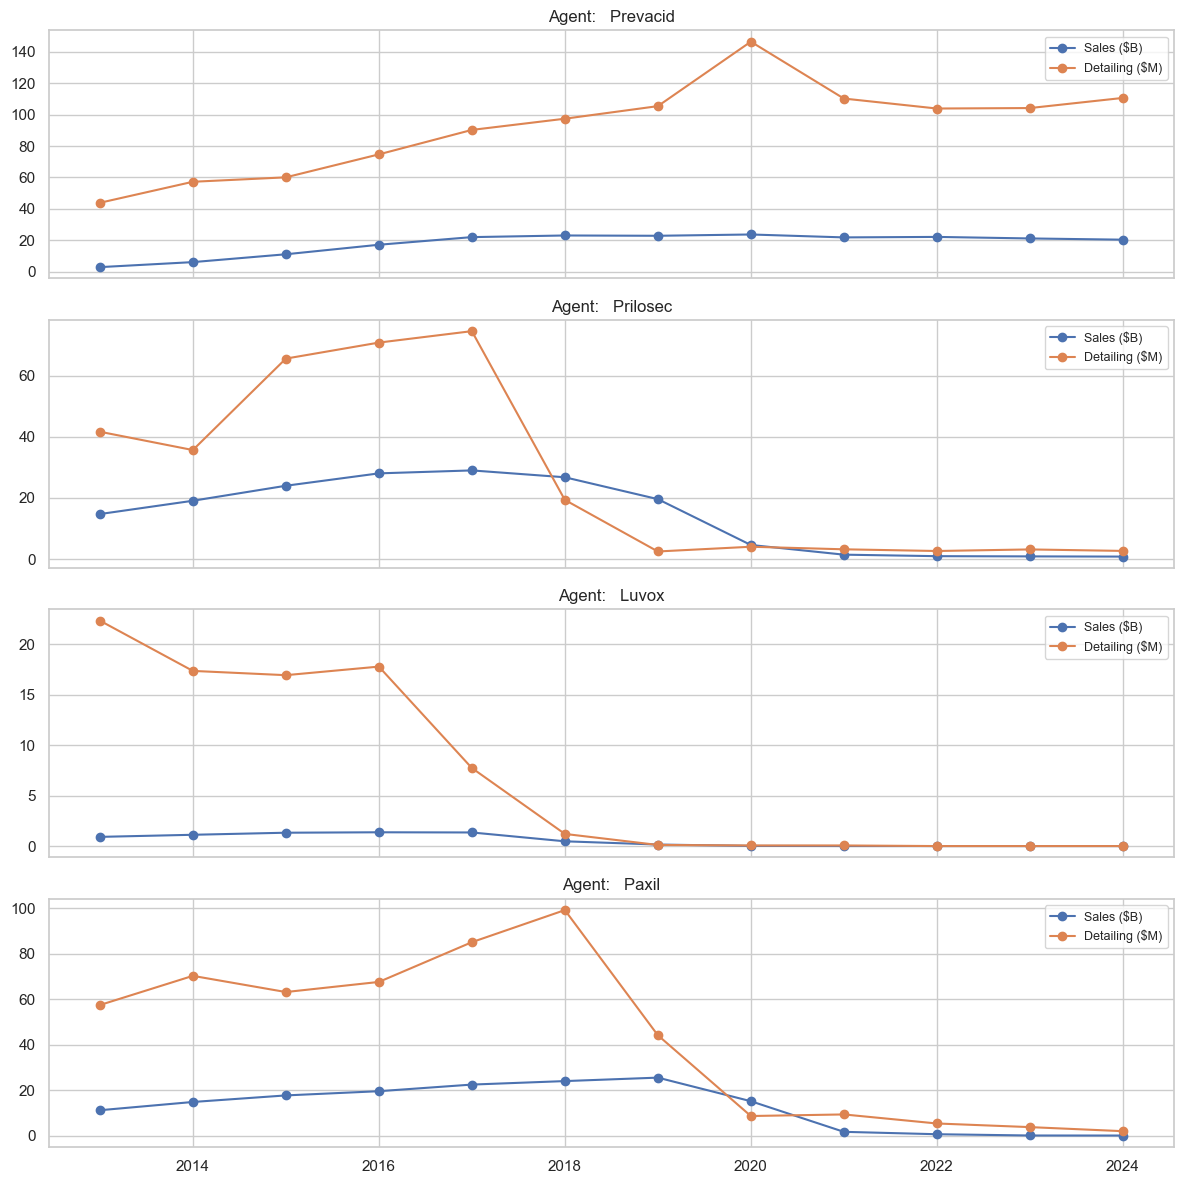


--- Observation ---
Prevacid: Detailing rises sharply while sales stay flat around $20B —
  suggests diminishing returns to detailing for this brand.
Prilosec: Detailing collapses post-2018, sales follow downward — consistent
  with managed decline (generic competition).
Luvox: Both detailing and sales are low and stable — niche brand, minimal
  identifying variation for response estimation.
Paxil: Dramatic detailing withdrawal around 2019-2020, sales decline in
  tandem — strong within-agent evidence that detailing cuts hurt sales.

These patterns confirm that within-brand marketing changes associate with
sales changes over time. This is the variation that fixed-effects models
will exploit for identification.



In [32]:
# Pick 4 agents that actually exist in the data
sample_agents = df["agent"].drop_duplicates().head(4).tolist()
print(f"Plotting agents: {sample_agents}")

fig, axes = plt.subplots(len(sample_agents), 1, figsize=(12, 12), sharex=True)
for i, a in enumerate(sample_agents):
    temp = df[df["agent"] == a].sort_values("year")
    if temp.empty:
        axes[i].set_title(f"Agent: {a} — NO DATA")
        continue
    axes[i].plot(temp["year"], temp["actual_sales"], marker="o", label="Sales ($B)")
    axes[i].plot(temp["year"], temp["detailing"], marker="o", label="Detailing ($M)")
    axes[i].set_title(f"Agent: {a}")
    axes[i].legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

print('''
--- Observation ---
Prevacid: Detailing rises sharply while sales stay flat around $20B —
  suggests diminishing returns to detailing for this brand.
Prilosec: Detailing collapses post-2018, sales follow downward — consistent
  with managed decline (generic competition).
Luvox: Both detailing and sales are low and stable — niche brand, minimal
  identifying variation for response estimation.
Paxil: Dramatic detailing withdrawal around 2019-2020, sales decline in
  tandem — strong within-agent evidence that detailing cuts hurt sales.

These patterns confirm that within-brand marketing changes associate with
sales changes over time. This is the variation that fixed-effects models
will exploit for identification.
''')

## 13. Marketing Intensity
Spend-per-dollar-of-sales ratios reveal which classes are marketing-heavy relative to revenue.

In [28]:
intensity_summary = (
    df.assign(
        detailing_intensity=df["detailing"] / df["actual_sales"],
        dtca_intensity=df["direct_to_consumer_ad"] / df["actual_sales"]
    )
    .groupby("class")[["detailing_intensity", "dtca_intensity"]]
    .mean()
    .sort_values("detailing_intensity", ascending=False)
)
display(intensity_summary)

print('''
--- Observation ---
Detailing intensity: Statins (26.1) spend the most per sales dollar on
  detailing. PPIs (10.9) are most efficient — stronger brand equity or
  greater DTCA substitution.
DTCA intensity: PPIs (2.6) lead, consistent with consumer-pull marketing.
  SSRIs (1.5) are lowest.

These differences suggest different optimal marketing mixes by class. The
elasticity estimates from the final model will determine whether high
intensity reflects genuine responsiveness or diminishing returns.
''')

,detailing_intensity,dtca_intensity
class,,
Statin,26.1372,2.1452
SSRI,14.2837,1.4505
PPI,10.8533,2.6465



--- Observation ---
Detailing intensity: Statins (26.1) spend the most per sales dollar on
  detailing. PPIs (10.9) are most efficient — stronger brand equity or
  greater DTCA substitution.
DTCA intensity: PPIs (2.6) lead, consistent with consumer-pull marketing.
  SSRIs (1.5) are lowest.

These differences suggest different optimal marketing mixes by class. The
elasticity estimates from the final model will determine whether high
intensity reflects genuine responsiveness or diminishing returns.



## 14. Outlier Check

In [29]:
print("Top 5 by Sales:")
display(df.nlargest(5, "actual_sales")[["class", "agent", "year", "actual_sales", "detailing", "direct_to_consumer_ad"]])

print("\nTop 5 by Detailing:")
display(df.nlargest(5, "detailing")[["class", "agent", "year", "actual_sales", "detailing", "direct_to_consumer_ad"]])

print("\nTop 5 by DTCA:")
display(df.nlargest(5, "direct_to_consumer_ad")[["class", "agent", "year", "actual_sales", "detailing", "direct_to_consumer_ad"]])

print('''
--- Observation ---
Sales: All top 5 are Lipitor ($56.8B-$63.2B). Structural outlier, not error.
Detailing: Top 4 are Lexapro ($203-243M) — highest detailing with near-zero
  DTCA, making it valuable for isolating the detailing effect.
DTCA: Top 3 are Nexium ($192-240K) — heaviest consumer advertiser, also high
  detailing, contributing to PPI-class collinearity.

None are data errors. Agent fixed effects absorb baseline differences. A
robustness check excluding Lipitor would strengthen confidence in estimates.
''')

Top 5 by Sales:


,class,agent,year,actual_sales,detailing,direct_to_consumer_ad
159,Statin,Lipitor,2022,63.2186,146.4874,93.4800
137,Statin,Lipitor,2021,62.5406,152.5107,110.7082
181,Statin,Lipitor,2023,62.0389,197.2503,142.6181
115,Statin,Lipitor,2020,58.6918,139.6403,108.3209
94,Statin,Lipitor,2019,56.7952,99.7099,79.1343



Top 5 by Detailing:


,class,agent,year,actual_sales,detailing,direct_to_consumer_ad
191,SSRI,Lexapro,2024,26.9766,243.3303,0.5963
125,SSRI,Lexapro,2021,22.3924,223.0231,0.2595
169,SSRI,Lexapro,2023,26.0019,215.6069,2.4667
203,Statin,Lipitor,2024,54.9727,203.9765,183.0804
104,SSRI,Lexapro,2020,13.5176,202.9746,0.0000



Top 5 by DTCA:


,class,agent,year,actual_sales,detailing,direct_to_consumer_ad
120,PPI,Nexium,2021,20.6499,168.0683,240.3550
142,PPI,Nexium,2022,22.8833,172.8186,225.8439
99,PPI,Nexium,2020,18.5523,160.8279,215.2616
134,Statin,Crestor,2021,6.3594,200.9031,213.3158
79,PPI,Nexium,2019,13.1240,145.5416,192.2922



--- Observation ---
Sales: All top 5 are Lipitor ($56.8B-$63.2B). Structural outlier, not error.
Detailing: Top 4 are Lexapro ($203-243M) — highest detailing with near-zero
  DTCA, making it valuable for isolating the detailing effect.
DTCA: Top 3 are Nexium ($192-240K) — heaviest consumer advertiser, also high
  detailing, contributing to PPI-class collinearity.

None are data errors. Agent fixed effects absorb baseline differences. A
robustness check excluding Lipitor would strengthen confidence in estimates.



## 15. EDA Takeaways

In [30]:
print('''
=== EDA Takeaways: Evidence for Model Specification ===

1. FUNCTIONAL FORM
   All three variables are right-skewed (sales 1.71, detailing 1.04, DTCA 2.30).
   Log(1+x) reduces skewness to near-symmetric and linearizes the Sales-Detailing
   relationship. A log-log specification is justified — coefficients will be
   interpretable as elasticities.

2. PANEL STRUCTURE
   The panel is unbalanced: 207 of 264 possible rows. Several agents enter between
   2016-2020. All test-period agents must appear in training to avoid cold-start
   prediction errors.

3. ZERO-DTCA REGIME
   47% of observations have zero DTCA, concentrated in SSRIs (58% zero). This is
   a structural regime difference. The dtca_zero binary indicator is available if
   residual diagnostics suggest the continuous log term alone is insufficient.

4. BASELINE HETEROGENEITY
   Agent baselines vary 50x+ (Lipitor $47B vs Luvox $0.9B). Class baselines differ
   by ~40%. Agent fixed effects or random intercepts are essential to prevent
   confounding brand equity with marketing responsiveness.

5. RESPONSE SLOPE HETEROGENEITY
   Faceted plots show class-specific sensitivities: SSRIs are more detailing-
   responsive, PPIs are more DTCA-responsive. This motivates interaction terms:
   log_detailing:C(Class) and log_dtca:C(Class).

6. COLLINEARITY
   log(Detailing) and log(DTCA) correlate at 0.60. Manageable, but SSRIs provide
   natural identification for detailing (near-zero DTCA variation in that class).

7. TEMPORAL DYNAMICS
   Non-linear arc in all variables — rising through ~2020, declining after. Year
   fixed effects C(Year) are necessary. Post-2020 structural shift challenges the
   time-based train/test split.

8. WITHIN-AGENT EVIDENCE
   Detailing withdrawal (Paxil, Prilosec) correlates with sales decline. Rising
   detailing without sales gains (Prevacid) suggests diminishing returns. This
   within-agent variation is what fixed-effects models exploit.

9. HIGH-LEVERAGE OBSERVATIONS
   Lipitor (sales), Lexapro (detailing), Nexium (DTCA) are genuine structural
   features. Robustness checks excluding Lipitor are recommended.

=== Proceeding to parametric modeling with: ===
  Response:     log_sales
  Predictors:   log_detailing, log_dtca
  Categoricals: C(Class), C(Agent), C(Year)
  Interactions: log_detailing:C(Class), log_dtca:C(Class)
''')


=== EDA Takeaways: Evidence for Model Specification ===

1. FUNCTIONAL FORM
   All three variables are right-skewed (sales 1.71, detailing 1.04, DTCA 2.30).
   Log(1+x) reduces skewness to near-symmetric and linearizes the Sales-Detailing
   relationship. A log-log specification is justified — coefficients will be
   interpretable as elasticities.

2. PANEL STRUCTURE
   The panel is unbalanced: 207 of 264 possible rows. Several agents enter between
   2016-2020. All test-period agents must appear in training to avoid cold-start
   prediction errors.

3. ZERO-DTCA REGIME
   47% of observations have zero DTCA, concentrated in SSRIs (58% zero). This is
   a structural regime difference. The dtca_zero binary indicator is available if
   residual diagnostics suggest the continuous log term alone is insufficient.

4. BASELINE HETEROGENEITY
   Agent baselines vary 50x+ (Lipitor $47B vs Luvox $0.9B). Class baselines differ
   by ~40%. Agent fixed effects or random intercepts are essential to 

In [31]:
df.to_csv("data/processed_eda.csv", index=False)
print("Saved: data/processed_eda.csv")
print(f"Columns exported: {df.columns.tolist()}")

Saved: data/processed_eda.csv
Columns exported: ['class', 'agent', 'year', 'detailing', 'direct_to_consumer_ad', 'actual_sales', 'log_sales', 'log_detailing', 'log_dtca', 'dtca_zero']
